# 15 · External evaluation and the generalization gap

The number this project exists to produce: internal held-out performance minus performance on a third population — for **every** classifier candidate, not just the winner, because the ranking does not have to survive the shift.

---

> **Where this sits.** `00 setup` → stage 1 candidates `01 YOLO` · `02 SAM` · `03 Moondream` → `04 seg shoot-out` → `05 crop dataset` → stage 2 candidates `06 InceptionV3` · `07 MaxViT-tiny` · `08 ResNet50` · `09 MobileNet+SVM` · `10 QSVM` → `11 cls shoot-out` → `12 Grad-CAM` → `13 external set` → `14 end-to-end` → `15 gap`. Every stage reads the previous one's artefacts from `runs_two_stage/`, so this notebook runs on its own — it does **not** need the others to be open.

> **Needs first:** `04`, `11` and `13`

### Bootstrap — environment, hardware profile, shared config

Identical in every notebook of this series. It detects where it is running
(**Colab/T4**, **IBEX/A100**, or local), turns on the right accelerations for that GPU, pins the
seed, and re-opens the shared `runs_two_stage/` folder so **any notebook can be run on its own** —
each stage reads the previous stage's artefacts from disk, not from memory.

**The A100 / T4 split is deliberate.** Only *throughput* knobs change with the GPU (batch size,
dataloader workers, AMP dtype, RAM caching, how many smears SAM pseudo-labels). *Capacity* knobs —
model size, image size, epochs — stay identical on both, so an A100 run and a T4 run remain
scientifically comparable. Every result file records the tier that produced it.

In [60]:
# ═════════════════════════════════════════════════════════════════════════════
#  SCD pipeline · shared bootstrap  (identical in every notebook of the series)
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart.

    On managed images (Kaggle / Colab / IBEX) pip usually lands in the per-user site
    directory. If that directory did not exist when python started, site.py never put it
    on sys.path -- so a fresh install stays invisible until the kernel is restarted.
    Re-adding the install targets by hand is what removes the "restart and run all" step.
    '''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
            print('  + sys.path', d)
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often offline.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break cudf/numba for the rest of the session.
    '''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    base = [sys.executable, '-m', 'pip', 'install', '-q']
    log = []
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        r = subprocess.run(base + extra + list(miss), capture_output=True, text=True)
        log.append((extra, r.stdout, r.stderr))
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    for extra, out, err in log:                      # only reached when it truly failed
        print('--- pip', *extra, '---')
        print((out or '')[-1500:], (err or '')[-1500:], sep='')
    raise ImportError(
        'could not import after installing: ' + ', '.join(miss) +
        '\n  pip output is above. If it shows a successful install, restart the kernel'
        '\n  and re-run -- the packages are on disk but not on this process sys.path.'
        '\n  On an offline node, install them by hand first.')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


# cv2 normally rides in with ultralytics, but an ultralytics that is already present
# (or a pip that could not reach the network) leaves no opencv behind -- ask for it.
_ensure(('cv2', 'opencv-python-headless'),
        ('ultralytics', 'ultralytics'), ('kagglehub', 'kagglehub'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── where are we? ────────────────────────────────────────────────────────────
if 'google.colab' in sys.modules:
    PLATFORM = 'colab'
elif os.environ.get('SLURM_JOB_ID') or os.path.isdir('/ibex'):
    PLATFORM = 'ibex'
else:
    PLATFORM = 'local'

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV = 'cuda'
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, GPU, CAP, VRAM = 'cpu', 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# bf16 has fp32's exponent range -> no GradScaler, no overflow. fp16 (T4) still needs the scaler.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'

if CAP[0] >= 8:                      # Ampere+: ~2x on every fp32 matmul/conv, for free
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# throughput knobs ONLY -- see the markdown above for why capacity knobs are not in here
PROFILE = {
    'a100': dict(workers=8, prefetch=4, cls_batch=64, sam_embed_batch=8, sam_box_batch=32,
                 yolo_cache='ram', sam_points_bulk=32, sam_qc_smears=30, md_batch=8,
                 sam_max={'cuba_full': 200, 'uganda_clean': 200, 'uganda_neg': 100}),
    't4':   dict(workers=2, prefetch=2, cls_batch=32, sam_embed_batch=2, sam_box_batch=8,
                 yolo_cache=False, sam_points_bulk=24, sam_qc_smears=20, md_batch=2,
                 sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
    'cpu':  dict(workers=0, prefetch=2, cls_batch=8, sam_embed_batch=1, sam_box_batch=4,
                 yolo_cache=False, sam_points_bulk=16, sam_qc_smears=4, md_batch=1,
                 sam_max={'cuba_full': 6, 'uganda_clean': 6, 'uganda_neg': 3}),
}[TIER]

CFG = {
    # --- where things live (env vars win, so an sbatch script can set them) -------------------
    'data_root':  os.environ.get('SCD_DATA_ROOT', ''),
    'runs_dir':   os.environ.get('SCD_RUNS_DIR', ''),
    'drive_hints': ['/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    'local_hints': [os.path.join(os.getcwd(), 'data', 'Sickle_Cell_Dataset'),  # unzipped next to the notebooks
                    os.path.expanduser('~/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Downloads/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Desktop/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Documents/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/scratch/Sickle_Cell_Dataset'),
                    f"/ibex/user/{os.environ.get('USER', '')}/Sickle_Cell_Dataset",
                    os.getcwd(), os.path.join(os.getcwd(), 'data'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'),
                    # IBEX keeps real data off $HOME (small quota); these are the usual homes for
                    # it, and the /ibex/*/USER globs catch project allocations without hard-coding
                    # a project code. Cheap: only existing dirs survive the filter below.
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                    f"/ibex/ai/home/{os.environ.get('USER', '')}",
                    *sorted(glob.glob(f"/ibex/*/{os.environ.get('USER', 'no-such-user')}")),
                    *sorted(glob.glob(f"/ibex/*/*/{os.environ.get('USER', 'no-such-user')}")),
                    # last resort -- broad sweeps, may pick up duplicate copies of the dataset
                    os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    '/content'],

    # --- stage 1: segmentation (capacity knobs -- identical on A100 and T4) -------------------
    'yolo_weights': 'yolo11s-seg.pt',   # A100 upgrade: 'yolo11m-seg.pt' (then re-run 01 AND 04)
    'yolo_imgsz':   1024,               # auto-falls back to 640 on CUDA OOM
    'yolo_epochs':  100,
    'yolo_patience': 20,
    'sam_variant':  'vit_b',            # A100 upgrade: 'vit_h' (record it -- it changes the result)
    'sam_side':     1024,
    'sam_points_bench': 32,             # points_per_side used for the BENCHMARK (never tier-scaled)
    'sam_ft_epochs': 20,
    'sam_ft_lr':    1e-4,
    'seg_val_frac': 0.20,               # held-out SMEARS
    'eval_side':    1024,               # long side every segmenter is benchmarked at

    # --- moondream ----------------------------------------------------------------------------
    'md_model':     'vikhyatk/moondream2',
    'md_prompts':   ['red blood cell', 'blood cell', 'cell', 'erythrocyte', 'round red cell'],
    'md_finetune':  True,               # falls back to prompt-calibrated zero-shot, loudly

    # --- stage 2: classification (5 candidates, one shared trainer + one shared scorer) --------
    'epochs_head': 8,                   # phase 1 -- frozen backbone, new head only
    'epochs_ft': 12,                    # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head': 1e-3,
    'lr_ft': 1e-4,
    'cuba_block': 10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac': 0.15,
    'test_frac': 0.15,

    # --- the two shallow candidates -----------------------------------------------------------
    'svm_C_grid': [0.1, 1.0, 10.0, 100.0],
    'svm_gamma_grid': ['scale', 0.01, 0.001],
    'qsvm_qubits': 8,                   # = PCA components; statevector is 2**this
    'qsvm_reps': 2,                     # ZZFeatureMap repetitions
    'qsvm_max_train': 4000,             # caps the N x N kernel; -1 = no cap
    'qsvm_bandwidth_grid': [1.0, 0.5, 0.25, 0.125, 0.0625],   # THE knob -- see notebook 10

    # --- stage 3: the unseen external test set ------------------------------------------------
    'external_kaggle_id': '',
    'external_candidates': ['alitaqishah/blood-cell-anomaly-detection-2025',
                            'fenicxs/sickle-cell-anaemia'],
    'external_zenodo': '7801430',
    'external_max_mb': 500,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    **PROFILE,
}

CFG['batch'] = CFG['cls_batch']

# ── output root: survives a Colab reconnect, lives on scratch under SLURM ─────
_drive = next((h for h in CFG['drive_hints'] if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(_drive or os.getcwd(), 'runs_two_stage')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')     # stage-1 shoot-out results
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')    # stage-2 shoot-out results
FEAT = os.path.join(CFG['runs_dir'], 'features')       # cached frozen-backbone embeddings
for _d in (FIG, WTS, TAB, BENCH, CBENCH, FEAT):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    '''everything earlier notebooks resolved (paths, split, measured constants)'''
    if os.path.exists(STATE_PATH):
        return json.load(open(STATE_PATH))
    return {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, nb='00_setup_and_data.ipynb'):
    '''fetch values produced by an earlier notebook, with an error that says which one'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run {nb} first (it writes them)')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
SPLIT = {'internal': '#4C72B0', 'external': '#DD8452'}
METHOD_CLR = {'yolo11-seg': '#2E86C1', 'sam-zeroshot': '#95A5A6',
              'sam-finetuned': '#27AE60', 'moondream': '#8E44AD',
              'inceptionv3': '#2E86C1', 'maxvit_tiny': '#8E44AD', 'resnet50': '#E67E22',
              'mobilenet_svm': '#27AE60', 'qsvm_zz': '#C0392B', 'svm_rbf_pca': '#95A5A6'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  if os.environ.get('SLURM_JOB_ID') else ''))
print(f'device     {GPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, AMP {AMP_DTYPE}')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'runs_dir   {CFG["runs_dir"]}')
if DEV == 'cpu':
    print('!! NO GPU -- Colab: Runtime > Change runtime type > T4.  IBEX: srun --gres=gpu:a100:1')

platform   ibex  | SLURM job 49852566
device     NVIDIA A100-SXM4-80GB | 79 GB | sm_80  ->  tier 'a100', AMP torch.bfloat16
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
runs_dir   /home/bahajao/runs_two_stage


In [61]:
# ── small utilities shared by every stage ────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')     # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''fp16 (T4) needs loss scaling; bf16 (A100) does not. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    '''free_gpu('sam', 'amg') -- drops the notebook globals, then empties the cache'''
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()

## External evaluation and the generalization gap

**The number this whole project exists to produce.** The identical `full_eval` suite, on data from a
third population, a different microscope and a different stain protocol — that is what says whether
a Cuba+Uganda pipeline is a *sickle-cell detector* or a *Cuba-and-Uganda detector*.

* **crops** → the winning classifier is scored directly per cell (segmentation is not scored here —
  it has no external ground truth, and the notebook-04 numbers are stated as internal-only);
* **full smears** → the whole pipeline runs and per-smear predictions are aggregated against the
  smear-level label.

**Every candidate is carried across, not just the winner.** All five stage-2 models are re-scored on
the external set, because the model that wins internally is not necessarily the one that survives a
distribution shift — and if the ranking reorders between the two, that reordering *is* the finding.

Then the **error-propagation budget**, because a two-stage pipeline can only classify the cells
stage 1 actually handed it:

$$\text{end-to-end accuracy} \;\le\; \underbrace{\text{segmenter instance recall}}_{\text{cells reached}}
\times \underbrace{\text{classifier per-cell accuracy}}_{\text{cells named correctly}}$$

Both factors are already measured — recall by the notebook-04 shoot-out, accuracy by `full_eval` —
so the ceiling is read off, not re-estimated.

In [62]:
# ═════════════════════════════════════════════════════════════════════════════
#  SHARED STAGE-2 MACHINERY -- byte-identical in notebooks 06-11
# ═════════════════════════════════════════════════════════════════════════════
import torchvision.models as tvm
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, f1_score,
                             precision_recall_fscore_support, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

NORM = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


def TF_EVAL(size):
    return transforms.Compose([transforms.ToTensor(),
                               transforms.Resize((size, size), antialias=True), NORM])


def TF_TRAIN(size):
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((size, size), antialias=True),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.RandomResizedCrop(size, scale=(0.8, 1.0), antialias=True),
        NORM])


# each backbone: native input size, which params are the "head", which blocks phase 2 unfreezes,
# and the layer Grad-CAM should look at.
BACKBONES = {
    'inceptionv3': dict(size=299, head=('fc', 'AuxLogits.fc'),
                        unfreeze=('Mixed_6', 'Mixed_7', 'fc', 'AuxLogits'), cam='Mixed_7c'),
    'maxvit_tiny': dict(size=224, head=('classifier',),
                        unfreeze=('blocks.2', 'blocks.3', 'classifier'), cam='blocks'),
    'resnet50':    dict(size=224, head=('fc',),
                        unfreeze=('layer3', 'layer4', 'fc'), cam='layer4'),
    'mobilenetv3': dict(size=224, head=('classifier',),
                        unfreeze=('features.14', 'features.15', 'features.16', 'classifier'),
                        cam='features'),
}


def build_backbone(name, headless=False):
    '''ImageNet-pretrained backbone with a 2-class head (or no head, for feature extraction)'''
    if name == 'inceptionv3':
        m = tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1)
        m.fc = nn.Identity() if headless else nn.Linear(m.fc.in_features, 2)
        if not headless:                                   # inception has TWO heads
            m.AuxLogits.fc = nn.Linear(m.AuxLogits.fc.in_features, 2)
    elif name == 'maxvit_tiny':
        m = tvm.maxvit_t(weights=tvm.MaxVit_T_Weights.IMAGENET1K_V1)
        m.classifier[-1] = nn.Identity() if headless else \
            nn.Linear(m.classifier[-1].in_features, 2)
    elif name == 'resnet50':
        m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Identity() if headless else nn.Linear(m.fc.in_features, 2)
    elif name == 'mobilenetv3':
        m = tvm.mobilenet_v3_large(weights=tvm.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        m.classifier[-1] = nn.Identity() if headless else \
            nn.Linear(m.classifier[-1].in_features, 2)
    else:
        raise ValueError(f'unknown backbone {name!r} -- one of {list(BACKBONES)}')
    return m.to(DEV, memory_format=torch.channels_last)


class CropDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        return self.tf(load_rgb(r.path)), int(r.y)


def loader(df, tf, shuffle=False, bs=None):
    '''pinned + persistent workers on A100, plain on T4/CPU'''
    kw = dict(batch_size=bs or CFG['cls_batch'], shuffle=shuffle, num_workers=CFG['workers'],
              pin_memory=(DEV == 'cuda'), drop_last=False)
    if CFG['workers'] > 0:
        kw.update(persistent_workers=True, prefetch_factor=CFG['prefetch'])
    return DataLoader(CropDS(df, tf), **kw)


@torch.no_grad()
def predict(model, dl):
    model.eval()
    P, Y = [], []
    for xb, yb in dl:
        xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
        with autocast_ctx():
            out = model(xb)
        P.append(torch.softmax(out.float(), 1).cpu())
        Y.append(yb)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()


# ── the ONE metric suite: internal, external and every candidate go through it ──
def full_eval(y, prob, name, colour='#4C72B0', pred=None, quiet=False):
    p1 = prob[:, 1]
    pred = prob.argmax(1) if pred is None else np.asarray(pred)
    pr, rc, f1, sup = precision_recall_fscore_support(y, pred, labels=[0, 1], zero_division=0)
    rep = pd.DataFrame({'precision': pr, 'recall': rc, 'f1': f1, 'support': sup},
                       index=CFG['classes'])
    macro = f1_score(y, pred, average='macro')
    accu = float((pred == y).mean())
    both = len(np.unique(y)) == 2
    A = AP = float('nan')
    if both:
        fpr, tpr, _ = roc_curve(y, p1)
        A, AP = auc(fpr, tpr), average_precision_score(y, p1)

    if not quiet:
        fig, ax = plt.subplots(1, 5, figsize=(25, 4.4))
        cm = confusion_matrix(y, pred, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=CFG['classes']).plot(ax=ax[0], cmap='Blues',
                                                                      colorbar=False)
        ax[0].set_title(f'(a) confusion — counts\nacc={accu:.3f}')
        ConfusionMatrixDisplay(cm / np.maximum(cm.sum(1, keepdims=True), 1),
                               display_labels=CFG['classes']).plot(
            ax=ax[1], cmap='Blues', colorbar=False, values_format='.2f')
        ax[1].set_title('(b) confusion — row-normalised')
        if both:
            ax[2].plot(fpr, tpr, color=colour, label=f'AUC={A:.3f}')
            ax[2].plot([0, 1], [0, 1], '--', c='grey', lw=1)
            ax[2].legend()
            p_, r_, _ = precision_recall_curve(y, p1)
            ax[3].plot(r_, p_, color=colour, label=f'AP={AP:.3f}')
            ax[3].axhline(y.mean(), ls='--', c='grey', lw=1)
            ax[3].legend()
        else:
            for a in ax[2:4]:
                a.text(0.5, 0.5, 'single class present\n— ROC/PR undefined', ha='center')
        ax[2].set_title('(c) ROC')
        ax[2].set_xlabel('FPR')
        ax[2].set_ylabel('TPR')
        ax[3].set_title('(d) precision-recall')
        ax[3].set_xlabel('recall')
        ax[3].set_ylabel('precision')
        ax[4].bar(CFG['classes'], f1, color=[CLR['circular'], CLR['elongated']])
        ax[4].axhline(macro, ls='--', c='k', lw=1, label=f'macro-F1={macro:.3f}')
        ax[4].set_ylim(0, 1)
        ax[4].set_title('(e) per-class F1')
        ax[4].legend()
        slug = name.lower().replace(' ', '_').replace('-', '_')
        fig.suptitle(f'{name}  (n={len(y)})', y=1.04)
        savefig(fig, f'cls_{slug}.png')
        plt.show()
        print(f'\n=== {name} ===')
        print(rep.round(4).to_string())
        print(f'accuracy {accu:.4f} | macro-F1 {macro:.4f} | AUC {A:.4f} | AP {AP:.4f}')
        rep.to_csv(os.path.join(TAB, f'report_{slug}.csv'))
    return {'name': name, 'n': len(y), 'accuracy': accu, 'macro_f1': macro, 'auc': A, 'ap': AP,
            'f1_circular': f1[0], 'f1_elongated': f1[1],
            'recall_circular': rc[0], 'recall_elongated': rc[1]}


# ── the ONE stage-2 scorer: writes cls_bench/<method>.json ──
def cls_benchmark(method, y, prob, notes='', extra=None, colour=None):
    res = full_eval(y, prob, method, colour or METHOD_CLR.get(method, '#4C72B0'))
    res.update({'method': method, 'notes': notes, 'tier': TIER, 'gpu': GPU,
                'timestamp': time.strftime('%Y-%m-%d %H:%M')})
    res.update(extra or {})
    json.dump(res, open(os.path.join(CBENCH, f'{method}.json'), 'w'), indent=2, default=float)
    print(f'-> {os.path.join(CBENCH, method)}.json')
    return res


# ── the ONE deep-training loop: three architectures, identical recipe ──
def train_deep(name, colour=None):
    spec = BACKBONES[name]
    size = spec['size']
    ckpt = os.path.join(WTS, f'cls_{name}.pt')
    hist_p = os.path.join(TAB, f'cls_{name}_history.json')
    HK = ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1']

    cnt = np.bincount(sub('train').y, minlength=2)
    CLS_W = torch.tensor(len(sub('train')) / (2 * np.maximum(cnt, 1)),
                         dtype=torch.float32, device=DEV)

    def phase(model, params, lr, epochs, hist, tag, dls):
        train_dl, val_dl = dls
        opt = torch.optim.Adam(params, lr=lr)
        scaler = make_scaler()
        crit = nn.CrossEntropyLoss(weight=CLS_W)
        best = hist.get('best_f1', -1)
        for ep in range(epochs):
            model.train()
            tl = tc = tn = 0
            for xb, yb in train_dl:
                xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
                yb = yb.to(DEV, non_blocking=True)
                opt.zero_grad(set_to_none=True)
                with autocast_ctx():
                    out = model(xb)
                    if hasattr(out, 'logits'):            # inception's aux head, train mode only
                        logits = out.logits
                        loss = crit(logits, yb) + 0.4 * crit(out.aux_logits, yb)
                    else:
                        logits = out
                        loss = crit(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                tl += loss.item() * len(yb)
                tc += (logits.argmax(1) == yb).sum().item()
                tn += len(yb)
            pv, yv = predict(model, val_dl)
            acc = float((pv.argmax(1) == yv).mean())
            f1 = f1_score(yv, pv.argmax(1), average='macro')
            w = CLS_W.cpu().numpy()[yv]                   # same weighting as the training loss
            vl = float(-(np.log(pv[np.arange(len(yv)), yv] + 1e-9) * w).sum() / w.sum())
            for k, v in zip(HK, [tl / tn, tc / tn, vl, acc, f1]):
                hist[k].append(v)
            if f1 > best:
                best = f1
                torch.save(model.state_dict(), ckpt)
            print(f'  {name} {tag} ep{ep + 1:02d}  loss {tl / tn:.4f} acc {tc / tn:.4f} '
                  f'| val loss {vl:.4f} acc {acc:.4f} macroF1 {f1:.4f}')
        hist['best_f1'] = best
        return hist

    def run(bs):
        dls = (loader(sub('train'), TF_TRAIN(size), shuffle=True, bs=bs),
               loader(sub('val'), TF_EVAL(size), bs=bs))
        m = build_backbone(name)
        h = {k: [] for k in HK}
        for p in m.parameters():                          # phase 1: heads only
            p.requires_grad = False
        head = [p for n_, p in m.named_parameters() if n_.startswith(spec['head'])]
        for p in head:
            p.requires_grad = True
        h = phase(m, head, CFG['lr_head'], CFG['epochs_head'], h, 'P1-head', dls)
        h['phase_switch'] = len(h['train_loss'])
        for n_, p in m.named_parameters():                # phase 2: top blocks
            if n_.startswith(spec['unfreeze']):
                p.requires_grad = True
        h = phase(m, [p for p in m.parameters() if p.requires_grad],
                  CFG['lr_ft'], CFG['epochs_ft'], h, 'P2-ft  ', dls)
        return m, h

    model = build_backbone(name)
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEV))      # <- rerun-safe
        hist = json.load(open(hist_p)) if os.path.exists(hist_p) else {k: [] for k in HK}
        print(f'loaded trained {name} ->', ckpt)
    else:
        t0 = time.time()
        try:
            model, hist = run(CFG['cls_batch'])
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            print(f'!! CUDA OOM at batch {CFG["cls_batch"]} -- retrying at {CFG["cls_batch"] // 2}')
            model, hist = run(max(CFG['cls_batch'] // 2, 4))
        hist['minutes'] = (time.time() - t0) / 60
        hist['tier'] = TIER
        json.dump(hist, open(hist_p, 'w'))
        print(f'{name} trained in {hist["minutes"]:.1f} min on {GPU}')
        model.load_state_dict(torch.load(ckpt, map_location=DEV))
    model.eval()

    if hist['train_loss']:
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        ax[0].plot(hist['train_loss'], label='train')
        ax[0].plot(hist['val_loss'], label='val')
        ax[1].plot(hist['train_acc'], label='train')
        ax[1].plot(hist['val_acc'], label='val')
        ax[2].plot(hist['val_f1'], color=colour or '#8E44AD', label='val macro-F1')
        for a, t in zip(ax, ['(a) loss', '(b) accuracy', '(c) val macro-F1 (model selection)']):
            a.set_title(t)
            a.set_xlabel('epoch')
            a.legend(fontsize=8)
            if 'phase_switch' in hist:
                a.axvline(hist['phase_switch'] - 0.5, ls='--', c='grey', lw=1)
        fig.suptitle(f'{name} two-phase fine-tuning (dashed = freeze → unfreeze)', y=1.03)
        savefig(fig, f'cls_{name}_curves.png')
        plt.show()
    return model, hist, ckpt


# ── frozen-backbone embeddings, cached so SVM and QSVM read identical features ──
@torch.no_grad()
def extract_features(name, split):
    f = os.path.join(FEAT, f'{name}_{split}.npz')
    if os.path.exists(f):                                              # <- rerun-safe
        d = np.load(f)
        return d['X'], d['y']
    m = build_backbone(name, headless=True).eval()
    dl = loader(sub(split), TF_EVAL(BACKBONES[name]['size']))
    X, Y = [], []
    for xb, yb in dl:
        xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
        with autocast_ctx():
            X.append(m(xb).float().cpu().numpy())
        Y.append(yb.numpy())
    X, Y = np.concatenate(X), np.concatenate(Y)
    np.savez_compressed(f, X=X, y=Y)
    free_gpu()
    print(f'  {name} {split}: {X.shape} -> {f}')
    return X, Y


# ── quantum-kernel helpers: used by notebook 10, and by build_classifier if QSVM wins ────
#    Exact simulation of qiskit's ZZFeatureMap fidelity kernel. Per repetition the map is
#    H^(x)n followed by the diagonal unitary whose phase on basis state |b> is
#        sum_i 2*x_i*b_i  +  sum_{i<j} 2*(pi-x_i)*(pi-x_j)*(b_i XOR b_j)
#    so a fast Walsh-Hadamard transform plus a phase multiply reproduces it to machine
#    precision -- O(N) statevectors instead of O(N^2) circuit executions.
QNQ, QREPS = CFG['qsvm_qubits'], CFG['qsvm_reps']
QDIM = 1 << QNQ
_QBITS = ((np.arange(QDIM)[:, None] >> np.arange(QNQ)[None, :]) & 1).astype(np.float64)
_QPAIRS = [(i, j) for i in range(QNQ) for j in range(i + 1, QNQ)]
_QXOR = np.stack([np.logical_xor(_QBITS[:, i], _QBITS[:, j]) for i, j in _QPAIRS],
                 1).astype(np.float64)


def hadamard_all(psi):
    '''H^(x)n on a batch of statevectors -- fast Walsh-Hadamard, exact'''
    v = psi.copy()
    h = 1
    while h < QDIM:
        v = v.reshape(v.shape[0], -1, 2 * h)
        a = v[:, :, :h].copy()
        b = v[:, :, h:].copy()
        v[:, :, :h] = a + b
        v[:, :, h:] = a - b
        v = v.reshape(v.shape[0], QDIM)
        h *= 2
    return v / (2 ** (QNQ / 2))


def zz_statevectors(X):
    '''|phi(x)> for ZZFeatureMap(reps=QREPS, entanglement="full"), simulated exactly'''
    X = np.asarray(X, np.float64)
    P = np.stack([(np.pi - X[:, i]) * (np.pi - X[:, j]) for i, j in _QPAIRS], 1)
    phase = 2.0 * (X @ _QBITS.T) + 2.0 * (P @ _QXOR.T)                     # (N, QDIM)
    psi = np.full((len(X), QDIM), 1.0 / np.sqrt(QDIM), dtype=np.complex128)  # = H^(x)n |0..0>
    psi *= np.exp(1j * phase)
    for _ in range(QREPS - 1):
        psi = hadamard_all(psi)
        psi *= np.exp(1j * phase)
    return psi


def fidelity_kernel(Pa, Pb):
    '''K[i,j] = |<phi(a_i)|phi(b_j)>|^2 -- one matmul instead of N*M circuit runs'''
    return np.abs(Pa.conj() @ Pb.T) ** 2

In [63]:
# ── re-open the crop split built in notebook 05 ──
crops = pd.read_csv(need('crops_csv', nb='05_classifier_dataset.ipynb'))


def sub(s):
    return crops[crops.split == s]


print(f"crops {len(crops)} | train {len(sub('train'))} / val {len(sub('val'))} / "
      f"test {len(sub('test'))}  (grouped by source smear)")

crops 1686 | train 1178 / val 250 / test 258  (grouped by source smear)


In [64]:
# ═════════════════════════════════════════════════════════════════════════════
#  The production classifier = whoever won the shoot-out in notebook 11.
#  Returns classify(list_of_rgb_crops) -> (N, 2) probabilities.
# ═════════════════════════════════════════════════════════════════════════════
def build_classifier(name=None):
    wf = os.path.join(CBENCH, 'cls_winner.json')
    if name is None:
        name = json.load(open(wf))['winner'] if os.path.exists(wf) else 'inceptionv3'
        print(f'classifier from the shoot-out -> {name}')

    if name in BACKBONES:                                   # a fine-tuned deep model
        size = BACKBONES[name]['size']
        m = build_backbone(name)
        m.load_state_dict(torch.load(os.path.join(WTS, f'cls_{name}.pt'), map_location=DEV))
        m.eval()
        tf = TF_EVAL(size)

        @torch.no_grad()
        def classify(crop_list):
            if not crop_list:
                return np.zeros((0, 2))
            out = []
            for i in range(0, len(crop_list), CFG['cls_batch']):
                x = torch.stack([tf(c) for c in crop_list[i:i + CFG['cls_batch']]])
                x = x.to(DEV, memory_format=torch.channels_last)
                with autocast_ctx():
                    out.append(torch.softmax(m(x).float(), 1).cpu())
            return torch.cat(out).numpy()
        return classify, name, m, size

    import joblib
    if name == 'mobilenet_svm':
        b = joblib.load(os.path.join(WTS, 'cls_mobilenet_svm.joblib'))
        size = BACKBONES[b['backbone']]['size']
        fx = build_backbone(b['backbone'], headless=True).eval()
        tf = TF_EVAL(size)

        @torch.no_grad()
        def classify(crop_list):
            if not crop_list:
                return np.zeros((0, 2))
            F_ = []
            for i in range(0, len(crop_list), CFG['cls_batch']):
                x = torch.stack([tf(c) for c in crop_list[i:i + CFG['cls_batch']]])
                x = x.to(DEV, memory_format=torch.channels_last)
                with autocast_ctx():
                    F_.append(fx(x).float().cpu().numpy())
            return b['svm'].predict_proba(b['scaler'].transform(np.concatenate(F_)))
        return classify, name, fx, size

    if name == 'qsvm_zz':
        b = joblib.load(os.path.join(WTS, 'cls_qsvm.joblib'))
        size = BACKBONES[b['backbone']]['size']
        fx = build_backbone(b['backbone'], headless=True).eval()
        tf = TF_EVAL(size)
        assert (b['nq'], b['reps']) == (QNQ, QREPS), (
            f"QSVM was fitted with {b['nq']} qubits / {b['reps']} reps but CFG now says "
            f'{QNQ}/{QREPS} -- the kernel would not match. Re-run 10 or restore the CFG values.')
        bw = b.get('bandwidth', 1.0)                   # angles were scaled into [0, bw*pi]
        Ptrain = zz_statevectors(b['train_enc'])       # fixed columns of the precomputed kernel

        @torch.no_grad()
        def classify(crop_list):
            if not crop_list:
                return np.zeros((0, 2))
            F_ = []
            for i in range(0, len(crop_list), CFG['cls_batch']):
                x = torch.stack([tf(c) for c in crop_list[i:i + CFG['cls_batch']]])
                x = x.to(DEV, memory_format=torch.channels_last)
                with autocast_ctx():
                    F_.append(fx(x).float().cpu().numpy())
            A = b['mm'].transform(b['pca'].transform(b['std'].transform(np.concatenate(F_)))) * bw
            return b['svm'].predict_proba(fidelity_kernel(zz_statevectors(A), Ptrain))
        return classify, name, fx, size

    raise ValueError(f'{name!r} has no production loader')


try:
    CLASSIFY, CLS_NAME, cls_model, CLS_SIZE = build_classifier()
except Exception as e:
    print(f'!! {type(e).__name__}: {e}\n   falling back to inceptionv3')
    CLASSIFY, CLS_NAME, cls_model, CLS_SIZE = build_classifier('inceptionv3')

classifier from the shoot-out -> inceptionv3


In [65]:
# ═════════════════════════════════════════════════════════════════════════════
#  The production segmenter = whoever won the shoot-out in notebook 04.
#  Returns bool masks in the coordinates of the image it was handed.
# ═════════════════════════════════════════════════════════════════════════════
def build_segmenter(name=None):
    wf = os.path.join(BENCH, 'seg_winner.json')
    if name is None:
        name = json.load(open(wf))['winner'] if os.path.exists(wf) else 'yolo11-seg'
        print(f'segmenter from the shoot-out -> {name}')

    if name.startswith('yolo'):
        from ultralytics import YOLO
        y = YOLO(need('yolo_weights_path', nb='01_segmentation_yolo.ipynb'))

        def seg(rgb):
            r = y.predict(rgb[:, :, ::-1], imgsz=CFG['yolo_imgsz'], conf=0.25,
                          retina_masks=True, verbose=False)[0]
            if r.masks is None:
                return []
            H, W = rgb.shape[:2]
            mk = r.masks.data.float().cpu().numpy()
            if mk.shape[1:] != (H, W):
                mk = np.stack([cv2.resize(x, (W, H), interpolation=cv2.INTER_NEAREST) for x in mk])
            return list(mk > 0.5)
        return seg, name

    if name.startswith('sam'):
        from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
        A1, preset = need('A1', 'sam_preset')
        s = sam_model_registry[CFG['sam_variant']](checkpoint=need('sam_ckpt')).to(DEV).eval()
        dec = read_state().get('sam_decoder_ckpt', '')
        if name.endswith('finetuned') and dec and os.path.exists(dec):
            s.mask_decoder.load_state_dict(torch.load(dec, map_location=DEV))
        gen = SamAutomaticMaskGenerator(s, points_per_side=CFG['sam_points_bench'],
                                        pred_iou_thresh=0.86, stability_score_thresh=0.90,
                                        min_mask_region_area=max(30, int(A1 * 1024 ** 2 / 16)))
        lo, hi, ar, sol = preset

        def seg(rgb):
            '''same fitted blob filter the benchmark used -- area, aspect AND solidity'''
            out = []
            A = rgb.shape[0] * rgb.shape[1]
            for m in gen.generate(rgb):
                x, yy, w, h = m['bbox']
                if not (lo * A <= m['area'] <= hi * A) or not w or not h:
                    continue
                if max(w / h, h / w) > ar:
                    continue
                cs, _ = cv2.findContours(m['segmentation'].astype(np.uint8),
                                         cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if not cs:
                    continue
                hull = cv2.contourArea(cv2.convexHull(max(cs, key=cv2.contourArea)))
                if hull > 0 and m['area'] / hull >= sol:
                    out.append(m['segmentation'])
            return out
        return seg, name

    raise ValueError(f'{name!r} is not usable as a production segmenter here -- '
                     "pass name='yolo11-seg' (Moondream returns boxes, not masks).")


try:
    SEGMENT, SEG_NAME = build_segmenter()
except Exception as e:
    print(f'!! {type(e).__name__}: {e}\n   falling back to YOLO')
    SEGMENT, SEG_NAME = build_segmenter('yolo11-seg')


def segment_and_classify(path, pad=0.15, max_side=2048):
    '''whole smear -> (rgb, list of masks, per-cell probabilities) -- both shoot-out winners'''
    im = load_rgb(path, max_side)
    masks, cell_crops = [], []
    for m in SEGMENT(im):
        ys, xs = np.nonzero(m)
        if len(xs) < 20:
            continue
        px = int((xs.max() - xs.min()) * pad) + 2
        py = int((ys.max() - ys.min()) * pad) + 2
        c = im[max(ys.min() - py, 0):ys.max() + py, max(xs.min() - px, 0):xs.max() + px]
        if c.size:
            masks.append(m)
            cell_crops.append(c)
    return im, masks, CLASSIFY(cell_crops)

segmenter from the shoot-out -> yolo11-seg


  external smear 25/569
  external smear 50/569
  external smear 75/569
  external smear 100/569
  external smear 125/569
  external smear 150/569
  external smear 175/569
  external smear 200/569
  external smear 225/569
  external smear 250/569
  external smear 275/569
  external smear 300/569
  external smear 325/569
  external smear 350/569
  external smear 375/569
  external smear 400/569
  external smear 425/569
  external smear 450/569
  external smear 475/569
  external smear 500/569
  external smear 525/569
  external smear 550/569


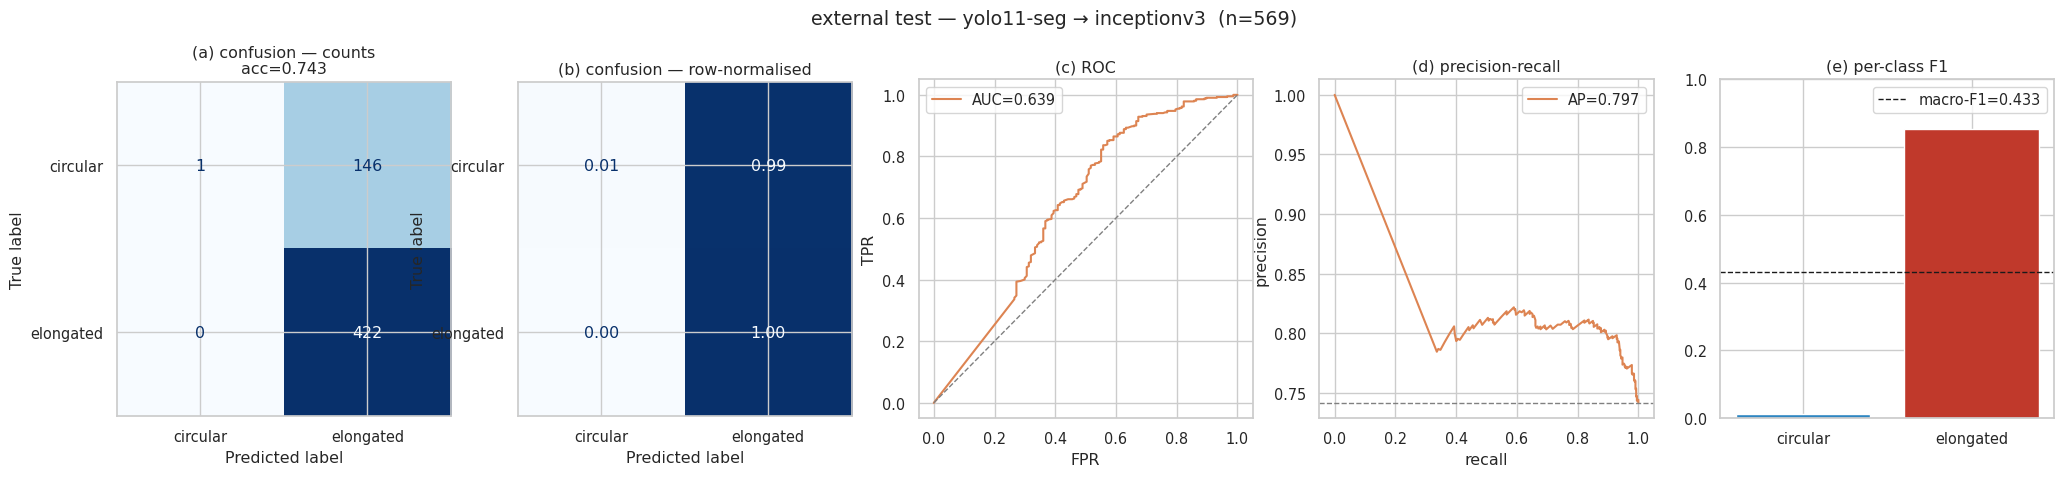


=== external test — yolo11-seg → inceptionv3 ===
           precision  recall      f1  support
circular       1.000  0.0068  0.0135      147
elongated      0.743  1.0000  0.8525      422
accuracy 0.7434 | macro-F1 0.4330 | AUC 0.6393 | AP 0.7969

Segmentation on external smears (no external masks exist -> descriptive only):
cells_per_smear_mean        59.63
cells_per_smear_median      59.00
smears_with_zero_cells       1.00
mean_mask_area_px         3756.51


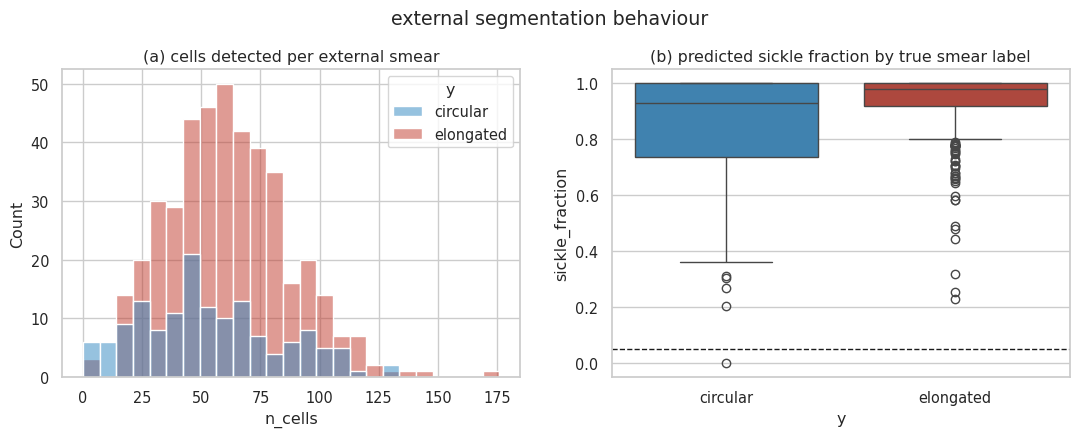

{'data_root': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset',
 'cuba_full': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/Cuba/full_smears',
 'cuba_circ': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/Cuba/cells_circular',
 'cuba_elong': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/Cuba/cells_elongated',
 'uganda_clean': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/Uganda/full_smears/positive_sickle_clean',
 'uganda_neg': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/Uganda/full_smears/negative_normal',
 'uga_elong': '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/Uganda/cells_elongated',
 'gt_dirs': ['/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/_supplementary/Cuba_masks_set2_50smears/01erythrocytesIDB2',
  '/ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset/_supplementary/Cuba_

In [66]:
ext_df = pd.read_csv(need('external_csv', nb='13_external_dataset.ipynb'))
EXT_ID, EXT_KIND = need('external_id', 'external_kind')
INTERNAL = json.load(open(os.path.join(CBENCH, f'{CLS_NAME}.json')))
SEG_EXT = None

EXT_IMGS = None
if EXT_KIND == 'crops':
    EXT_IMGS = [load_rgb(p) for p in ext_df.path]      # loaded ONCE, reused by every candidate
    y_ext = ext_df.y.values
    prob_ext = CLASSIFY(EXT_IMGS)
    EXTERNAL = full_eval(y_ext, prob_ext, f'external test — {CLS_NAME}', SPLIT['external'])
    EXTERNAL['mode'] = 'per-cell (classifier only)'
    print('\nSegmentation was NOT evaluated externally -- this dataset ships cell crops, not smears.')
else:
    rows = []
    for k, (p, y) in enumerate(zip(ext_df.path, ext_df.y)):
        im = load_rgb(p, 2048)
        masks = SEGMENT(im)
        cl = []
        for m in masks:
            ys, xs = np.nonzero(m)
            if len(xs) >= 20:
                cl.append(im[ys.min():ys.max() + 1, xs.min():xs.max() + 1])
        prob = CLASSIFY(cl)
        pred = prob.argmax(1) if len(prob) else np.array([])
        rows.append({'path': p, 'y': y, 'n_cells': len(cl),
                     'sickle_fraction': float((pred == 1).mean()) if len(pred) else 0.0,
                     'area_mean': float(np.mean([m.sum() for m in masks])) if masks else 0.0})
        if (k + 1) % 25 == 0:
            print(f'  external smear {k + 1}/{len(ext_df)}')
    ee = pd.DataFrame(rows)
    ee.to_csv(os.path.join(TAB, 'external_end_to_end.csv'), index=False)

    thr = 0.05
    score_ext = ee.sickle_fraction.values
    y_ext = ee.y.values
    EXTERNAL = full_eval(y_ext, np.stack([1 - score_ext, score_ext], 1),
                         f'external test — {SEG_NAME} → {CLS_NAME}', SPLIT['external'],
                         pred=(score_ext >= thr).astype(int))
    EXTERNAL['mode'] = f'end-to-end, smear-level (sickle_fraction >= {thr})'
    SEG_EXT = {'cells_per_smear_mean': float(ee.n_cells.mean()),
               'cells_per_smear_median': float(ee.n_cells.median()),
               'smears_with_zero_cells': int((ee.n_cells == 0).sum()),
               'mean_mask_area_px': float(ee.area_mean.mean())}
    print('\nSegmentation on external smears (no external masks exist -> descriptive only):')
    print(pd.Series(SEG_EXT).round(2).to_string())

    names = ee.y.map(dict(enumerate(CFG['classes'])))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(data=ee, x='n_cells', hue=names, ax=ax[0], palette=CLR, bins=25)
    ax[0].set_title('(a) cells detected per external smear')
    sns.boxplot(x=names, y=ee.sickle_fraction, ax=ax[1], palette=CLR)
    ax[1].axhline(thr, ls='--', c='k', lw=1)
    ax[1].set_title('(b) predicted sickle fraction by true smear label')
    fig.suptitle('external segmentation behaviour', y=1.03)
    savefig(fig, 'ext_segmentation.png')
    plt.show()

save_state(external_metrics=EXTERNAL)

In [67]:
# ── does the internal ranking survive the shift? Re-score EVERY candidate externally. ──
if EXT_KIND == 'crops':
    ext_rows = []
    for f in sorted(glob.glob(os.path.join(CBENCH, '*.json'))):
        m = os.path.basename(f)[:-5]
        if m == 'cls_winner':
            continue
        internal = json.load(open(f))
        try:
            clf, _, _, _ = build_classifier(m)
        except Exception as e:
            print(f'  [skip] {m}: {type(e).__name__} {str(e)[:80]}')
            continue
        pr = clf(EXT_IMGS)
        e = full_eval(ext_df.y.values, pr, f'external — {m}', quiet=True)
        ext_rows.append({'method': m, 'internal_macro_f1': internal['macro_f1'],
                         'external_macro_f1': e['macro_f1'],
                         'gap': internal['macro_f1'] - e['macro_f1'],
                         'internal_auc': internal['auc'], 'external_auc': e['auc'],
                         'ext_f1_circular': e['f1_circular'],
                         'ext_f1_elongated': e['f1_elongated']})
        print(f"  {m:16s} internal {internal['macro_f1']:.4f} -> external {e['macro_f1']:.4f} "
              f"({e['macro_f1'] - internal['macro_f1']:+.4f})")
        free_gpu('clf')

    xt = pd.DataFrame(ext_rows).sort_values('external_macro_f1', ascending=False)
    xt.to_csv(os.path.join(TAB, 'classifier_external_comparison.csv'), index=False)
    print('\n' + xt.round(4).to_string(index=False))

    fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
    xt.set_index('method')[['internal_macro_f1', 'external_macro_f1']].plot(
        kind='bar', ax=ax[0], color=[SPLIT['internal'], SPLIT['external']])
    ax[0].set_ylim(0, 1.05)
    ax[0].tick_params(axis='x', rotation=18)
    ax[0].set_title('(a) every candidate, internal vs external')
    for m_, a_, b_ in zip(xt.method, xt.internal_macro_f1, xt.external_macro_f1):
        ax[1].plot([0, 1], [a_, b_], marker='o', label=m_, color=METHOD_CLR.get(m_, '#7F8C8D'))
    ax[1].set_xticks([0, 1])
    ax[1].set_xticklabels(['internal', 'external'])
    ax[1].set_ylabel('macro-F1')
    ax[1].legend(fontsize=7)
    ax[1].set_title('(b) does the ranking survive the shift? (crossing lines = it does not)')
    fig.suptitle('classifier robustness under distribution shift', y=1.03)
    savefig(fig, 'gap_classifier_ranking.png')
    plt.show()

    ri, re_ = xt.sort_values('internal_macro_f1', ascending=False).method.tolist(), xt.method.tolist()
    print(f'\n  internal ranking: {" > ".join(ri)}')
    print(f'  external ranking: {" > ".join(re_)}')
    print('  -> ' + ('SAME winner both ways.' if ri[0] == re_[0] else
                     f'RANKING REORDERS: {ri[0]} wins internally, {re_[0]} externally. '
                     'The internal shoot-out is not a safe guide to deployment.'))
else:
    print('external set ships whole smears -- per-candidate re-scoring would need a full '
          'segment+classify pass each. Winner-only numbers above.')

external set ships whole smears -- per-candidate re-scoring would need a full segment+classify pass each. Winner-only numbers above.


error propagation, stage 1 = yolo11-seg on 17 held-out GT smears (466 real cells):
  instance recall   0.983   (cells stage 2 never sees: 1.7%)
  over-segmentation 0.414   (detections with no real cell behind them)
  end-to-end CEILING  internal 0.983 | external 0.731

              internal  external  absolute_gap  relative_drop_%
accuracy           1.0    0.7434        0.2566          25.6591
macro_f1           1.0    0.4330        0.5670          56.6981
auc                1.0    0.6393        0.3607          36.0722
f1_circular        1.0    0.0135        0.9865          98.6486
f1_elongated       1.0    0.8525        0.1475          14.7475


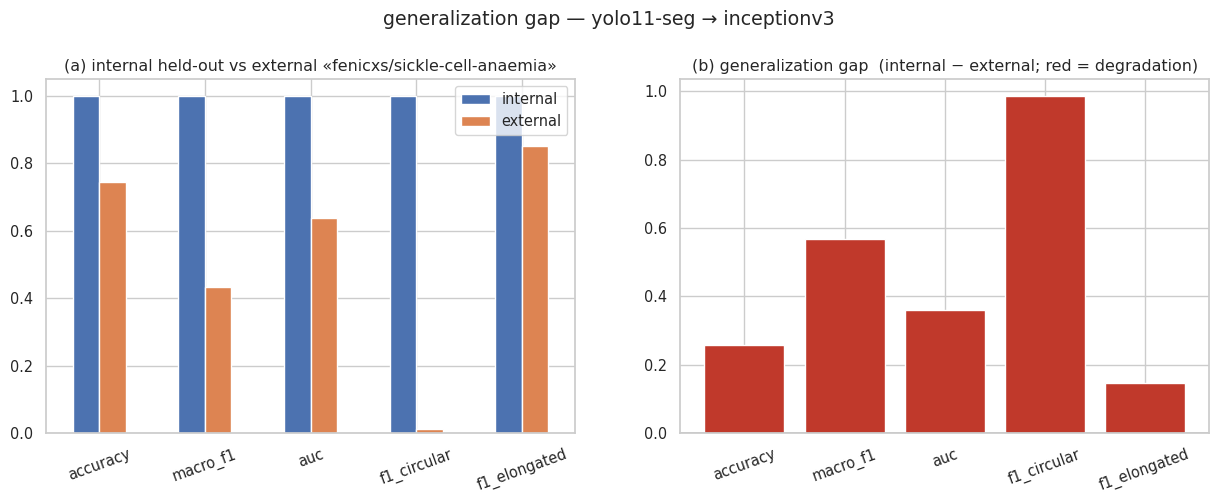

In [68]:
# ── error propagation, read straight off the notebook-04 shoot-out ──
wf = os.path.join(BENCH, 'seg_winner.json')
seg_res = {}
if os.path.exists(wf):
    win = json.load(open(wf))
    seg_res = json.load(open(os.path.join(BENCH, win['winner'] + '.json')))
    recall = seg_res['recall@50']
    over = 1 - seg_res['precision@50']
    ceiling_int = recall * INTERNAL['accuracy']
    ceiling_ext = recall * EXTERNAL['accuracy']
    print(f"error propagation, stage 1 = {win['winner']} on {seg_res['n_smears']} held-out GT "
          f"smears ({seg_res['gt_cells']} real cells):")
    print(f'  instance recall   {recall:.3f}   (cells stage 2 never sees: {(1 - recall) * 100:.1f}%)')
    print(f'  over-segmentation {over:.3f}   (detections with no real cell behind them)')
    print(f'  end-to-end CEILING  internal {ceiling_int:.3f} | external {ceiling_ext:.3f}')
else:
    recall = over = ceiling_int = ceiling_ext = float('nan')
    print('no seg_winner.json -- run notebook 04. Ceiling not computable.')

M = ['accuracy', 'macro_f1', 'auc', 'f1_circular', 'f1_elongated']
gap = pd.DataFrame({'internal': [INTERNAL[m] for m in M], 'external': [EXTERNAL[m] for m in M]},
                   index=M)
gap['absolute_gap'] = gap.internal - gap.external
gap['relative_drop_%'] = 100 * gap.absolute_gap / gap.internal.replace(0, np.nan)
gap.to_csv(os.path.join(TAB, 'generalization_gap.csv'))
print('\n' + '=' * 70)
print(gap.round(4).to_string())
print('=' * 70)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
gap[['internal', 'external']].plot(kind='bar', ax=ax[0],
                                   color=[SPLIT['internal'], SPLIT['external']])
ax[0].set_ylim(0, 1.05)
ax[0].tick_params(axis='x', rotation=20)
ax[0].set_title(f'(a) internal held-out vs external «{EXT_ID}»')
ax[1].bar(gap.index, gap.absolute_gap,
          color=['#7F8C8D' if v <= 0 else '#C0392B' for v in gap.absolute_gap])
ax[1].axhline(0, c='k', lw=1)
ax[1].tick_params(axis='x', rotation=20)
ax[1].set_title('(b) generalization gap  (internal − external; red = degradation)')
fig.suptitle(f'generalization gap — {SEG_NAME} → {CLS_NAME}', y=1.03)
savefig(fig, 'gap_generalization.png')
plt.show()

json.dump({'internal': INTERNAL, 'external': EXTERNAL, 'segmentation': seg_res,
           'segmentation_external': SEG_EXT, 'external_id': EXT_ID, 'external_kind': EXT_KIND,
           'ceiling_internal': ceiling_int, 'ceiling_external': ceiling_ext,
           'segmenter': SEG_NAME, 'classifier': CLS_NAME, 'tier': TIER, 'gpu': GPU},
          open(os.path.join(TAB, 'all_metrics.json'), 'w'), indent=2, default=float)

In [69]:
# ── the written result ──
d_f1 = gap.loc['macro_f1', 'absolute_gap']
verdict = 'HOLDS UP' if d_f1 < 0.05 else ('DEGRADES MODERATELY' if d_f1 < 0.15 else
                                          'DEGRADES SHARPLY')
print('=' * 78)
print(f'GENERALIZATION RESULT — trained on Cuba + Uganda, tested on {EXT_ID} ({EXT_KIND})')
print('=' * 78)
print(f'  pipeline          : {SEG_NAME} -> {CLS_NAME}  (both shoot-out winners)')
print(f'  internal held-out : acc {INTERNAL["accuracy"]:.3f} | macro-F1 {INTERNAL["macro_f1"]:.3f} '
      f'| AUC {INTERNAL["auc"]:.3f}')
print(f'  external unseen   : acc {EXTERNAL["accuracy"]:.3f} | macro-F1 {EXTERNAL["macro_f1"]:.3f} '
      f'| AUC {EXTERNAL["auc"]:.3f}')
print(f'  GAP               : acc {gap.loc["accuracy", "absolute_gap"]:+.3f} | '
      f'macro-F1 {d_f1:+.3f}')
print(f'                      per-class F1: circular {gap.loc["f1_circular", "absolute_gap"]:+.3f}, '
      f'elongated {gap.loc["f1_elongated", "absolute_gap"]:+.3f}')
print(f'  stage-1 cost      : {seg_res.get("method", "n/a")} instance recall {recall:.3f} '
      f'-> end-to-end ceiling {ceiling_ext:.3f} externally')
print(f'  evaluation mode   : {EXTERNAL["mode"]}')
print(f'  VERDICT           : the two-dataset-trained pipeline {verdict} on an unseen dataset.')
print('=' * 78)

GENERALIZATION RESULT — trained on Cuba + Uganda, tested on fenicxs/sickle-cell-anaemia (smears)
  pipeline          : yolo11-seg -> inceptionv3  (both shoot-out winners)
  internal held-out : acc 1.000 | macro-F1 1.000 | AUC 1.000
  external unseen   : acc 0.743 | macro-F1 0.433 | AUC 0.639
  GAP               : acc +0.257 | macro-F1 +0.567
                      per-class F1: circular +0.986, elongated +0.147
  stage-1 cost      : yolo11-seg instance recall 0.983 -> end-to-end ceiling 0.731 externally
  evaluation mode   : end-to-end, smear-level (sickle_fraction >= 0.05)
  VERDICT           : the two-dataset-trained pipeline DEGRADES SHARPLY on an unseen dataset.


### Interpreting the gap — confound vs genuine shift

Read the numbers above with this decomposition, which the pipeline is *instrumented to support*
rather than to assert:

* **Asymmetric per-class F1 collapse is the confound's signature.** `circular` was learned from Cuban
  cells only. If external `circular` F1 falls far more than external `elongated` F1, the healthy
  class was partly encoded as *"looks Cuban"*, and a non-Cuban healthy cell no longer matches. That
  is a **dataset-construction artifact, fixable with Ugandan/other healthy cells** — not evidence
  that morphology-based screening fails.
* **A symmetric drop across both classes is genuine distribution shift** — different stain
  (Leishman/field vs Giemsa), different optics (phone-through-eyepiece vs microscope camera),
  different magnification and focus. That is the real-world number a deployment would face.
* **Notebook 12 arbitrates.** Grad-CAM on cell bodies supports "genuine shift"; heat on plasma and
  field edges supports "confound".
* **The per-candidate table above is the second arbiter.** If all five architectures — CNN,
  transformer, classical SVM, quantum kernel — drop by roughly the same amount, the gap is in the
  data, and no amount of architecture search will close it. If they scatter, the ones that hold up
  are the ones leaning less on the shortcut.
* **Stage 1 caps everything.** External accuracy can never exceed `segmenter recall × classifier
  accuracy`. If the ceiling above is close to the observed external accuracy, the bottleneck is
  **segmentation**, and a better classifier will not help — go back to notebook 04 and take the
  runner-up seriously.

**To close the gap, in order of expected value:** (1) add non-Cuban healthy cells so `circular` stops
being a proxy for country; (2) stain-space augmentation or stain normalisation at train time;
(3) more segmentation ground truth outside Cuba, since the SAM-derived labels inherit the IoU
measured in notebook 00 as their quality bound.

All weights, metric tables (`tables/*.csv`, `all_metrics.json`, `seg_bench/*.json`,
`cls_bench/*.json`) and every figure are under `runs_two_stage/`.

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT  ·  identical in every notebook of the series
#
#  Appends one record per run to  runs_two_stage/checkpoints.json  -- the single
#  file that answers "which stages have actually been run, on what hardware, how
#  long did they take, what did they write to disk, and what did they score?".
#  Re-running a stage APPENDS; nothing is overwritten, so the file is the run
#  history of the whole pipeline rather than a snapshot of the last run.
# ═════════════════════════════════════════════════════════════════════════════
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    '''wall-clock minutes this kernel has been alive = how long the run took, near enough'''
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(nb, produced=None, metrics=None, status='ok', notes=''):
    '''record that `nb` finished. `produced` = {label: path}; a falsy path is skipped,
    which is how the optional artefacts (a run dir that was not recreated, a table only
    one branch writes) stay out of the missing list.'''
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb,
           'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'),
           'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'vram_gb': round(VRAM, 1),
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''),
           'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'          # atomic: two stages can finish at once
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print(f'  -> {CKPT_LOG}   ({len(log)} records)')
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<20s} {v}')
    last = {r['nb']: r for r in log}              # one row per stage, most recent run wins
    print(f'\n  stages recorded in this runs_dir ({len(last)}):')
    for k in sorted(last):
        r = last[k]
        print(f'   {"ok" if r["status"] == "ok" else "!!"}  {k:<40s} {r["finished"]}  '
              f'tier {r.get("tier", "?")}')
    return rec

checkpoint(
    '15_external_eval_and_gap',
    produced={'all_metrics': os.path.join(TAB, 'all_metrics.json'),
              'gap_csv': os.path.join(TAB, 'generalization_gap.csv'),
              'gap_figure': os.path.join(FIG, 'gap_generalization.png'),
              'ranking_csv': (os.path.join(TAB, 'classifier_external_comparison.csv')
                              if EXT_KIND == 'crops' else ''),
              'end_to_end_csv': (os.path.join(TAB, 'external_end_to_end.csv')
                                 if EXT_KIND == 'smears' else '')},
    metrics={'external_set': EXT_ID, 'kind': EXT_KIND, 'mode': EXTERNAL['mode'],
             'segmenter': SEG_NAME, 'classifier': CLS_NAME,
             'internal_macro_f1': INTERNAL['macro_f1'],
             'external_macro_f1': EXTERNAL['macro_f1'],
             'internal_accuracy': INTERNAL['accuracy'],
             'external_accuracy': EXTERNAL['accuracy'],
             'gap_macro_f1': d_f1,
             'gap_accuracy': gap.loc['accuracy', 'absolute_gap'],
             'stage1_recall@50': seg_res.get('recall@50'),
             'end_to_end_ceiling_external': ceiling_ext,
             'verdict': verdict},
    notes='the result the whole series exists to produce')